
📥 Downloading price data from Yahoo Finance...
   Period: 2022-01-01 → 2026-03-27

✅ Analysing 13 holdings.
   Date range: 2022-01-04 → 2026-03-26

📊 Computing performance metrics...

  FILTER 2a — PERFORMANCE ANALYTICS VERDICT
  Benchmark: VWRP  |  Risk-free rate: 4.5%  |  Pass threshold: ≥ 5/8
  ETF                                CAGR   Max DD   Sharpe   CVaR5%     Vol   Score   Verdict
--------------------------------------------------------------------------------------------------------------
  ★ VWRP (Backbone)              ✅  8.4%  ✅-17.6%  ⚠️  0.38   ✅-1.59%   10.9%     7/8   ✅ Proceed to P3
    Defence Tech (ARMG)          ✅ 60.5%  ✅-12.3%  ✅ 1.07   ⚠️ -2.70%   21.6%     7/8   ✅ Proceed to P3
    Healthcare S&P (XLVS)        ⚠️   2.7%  ✅-17.6%  ✅ 0.55   ✅-1.67%   14.7%     7/8   ✅ Proceed to P3
    Aero & Defence (DFND)        ✅  8.1%  ⚠️ -30.7%  ⚠️  0.30   ⚠️ -2.44%   18.4%     5/8   ✅ Proceed to P3
    Precious Metals (PHPP)       ✅ 18.6%  ⚠️ -26.9%  ✅ 1.87   ❌-6.27%   38.5

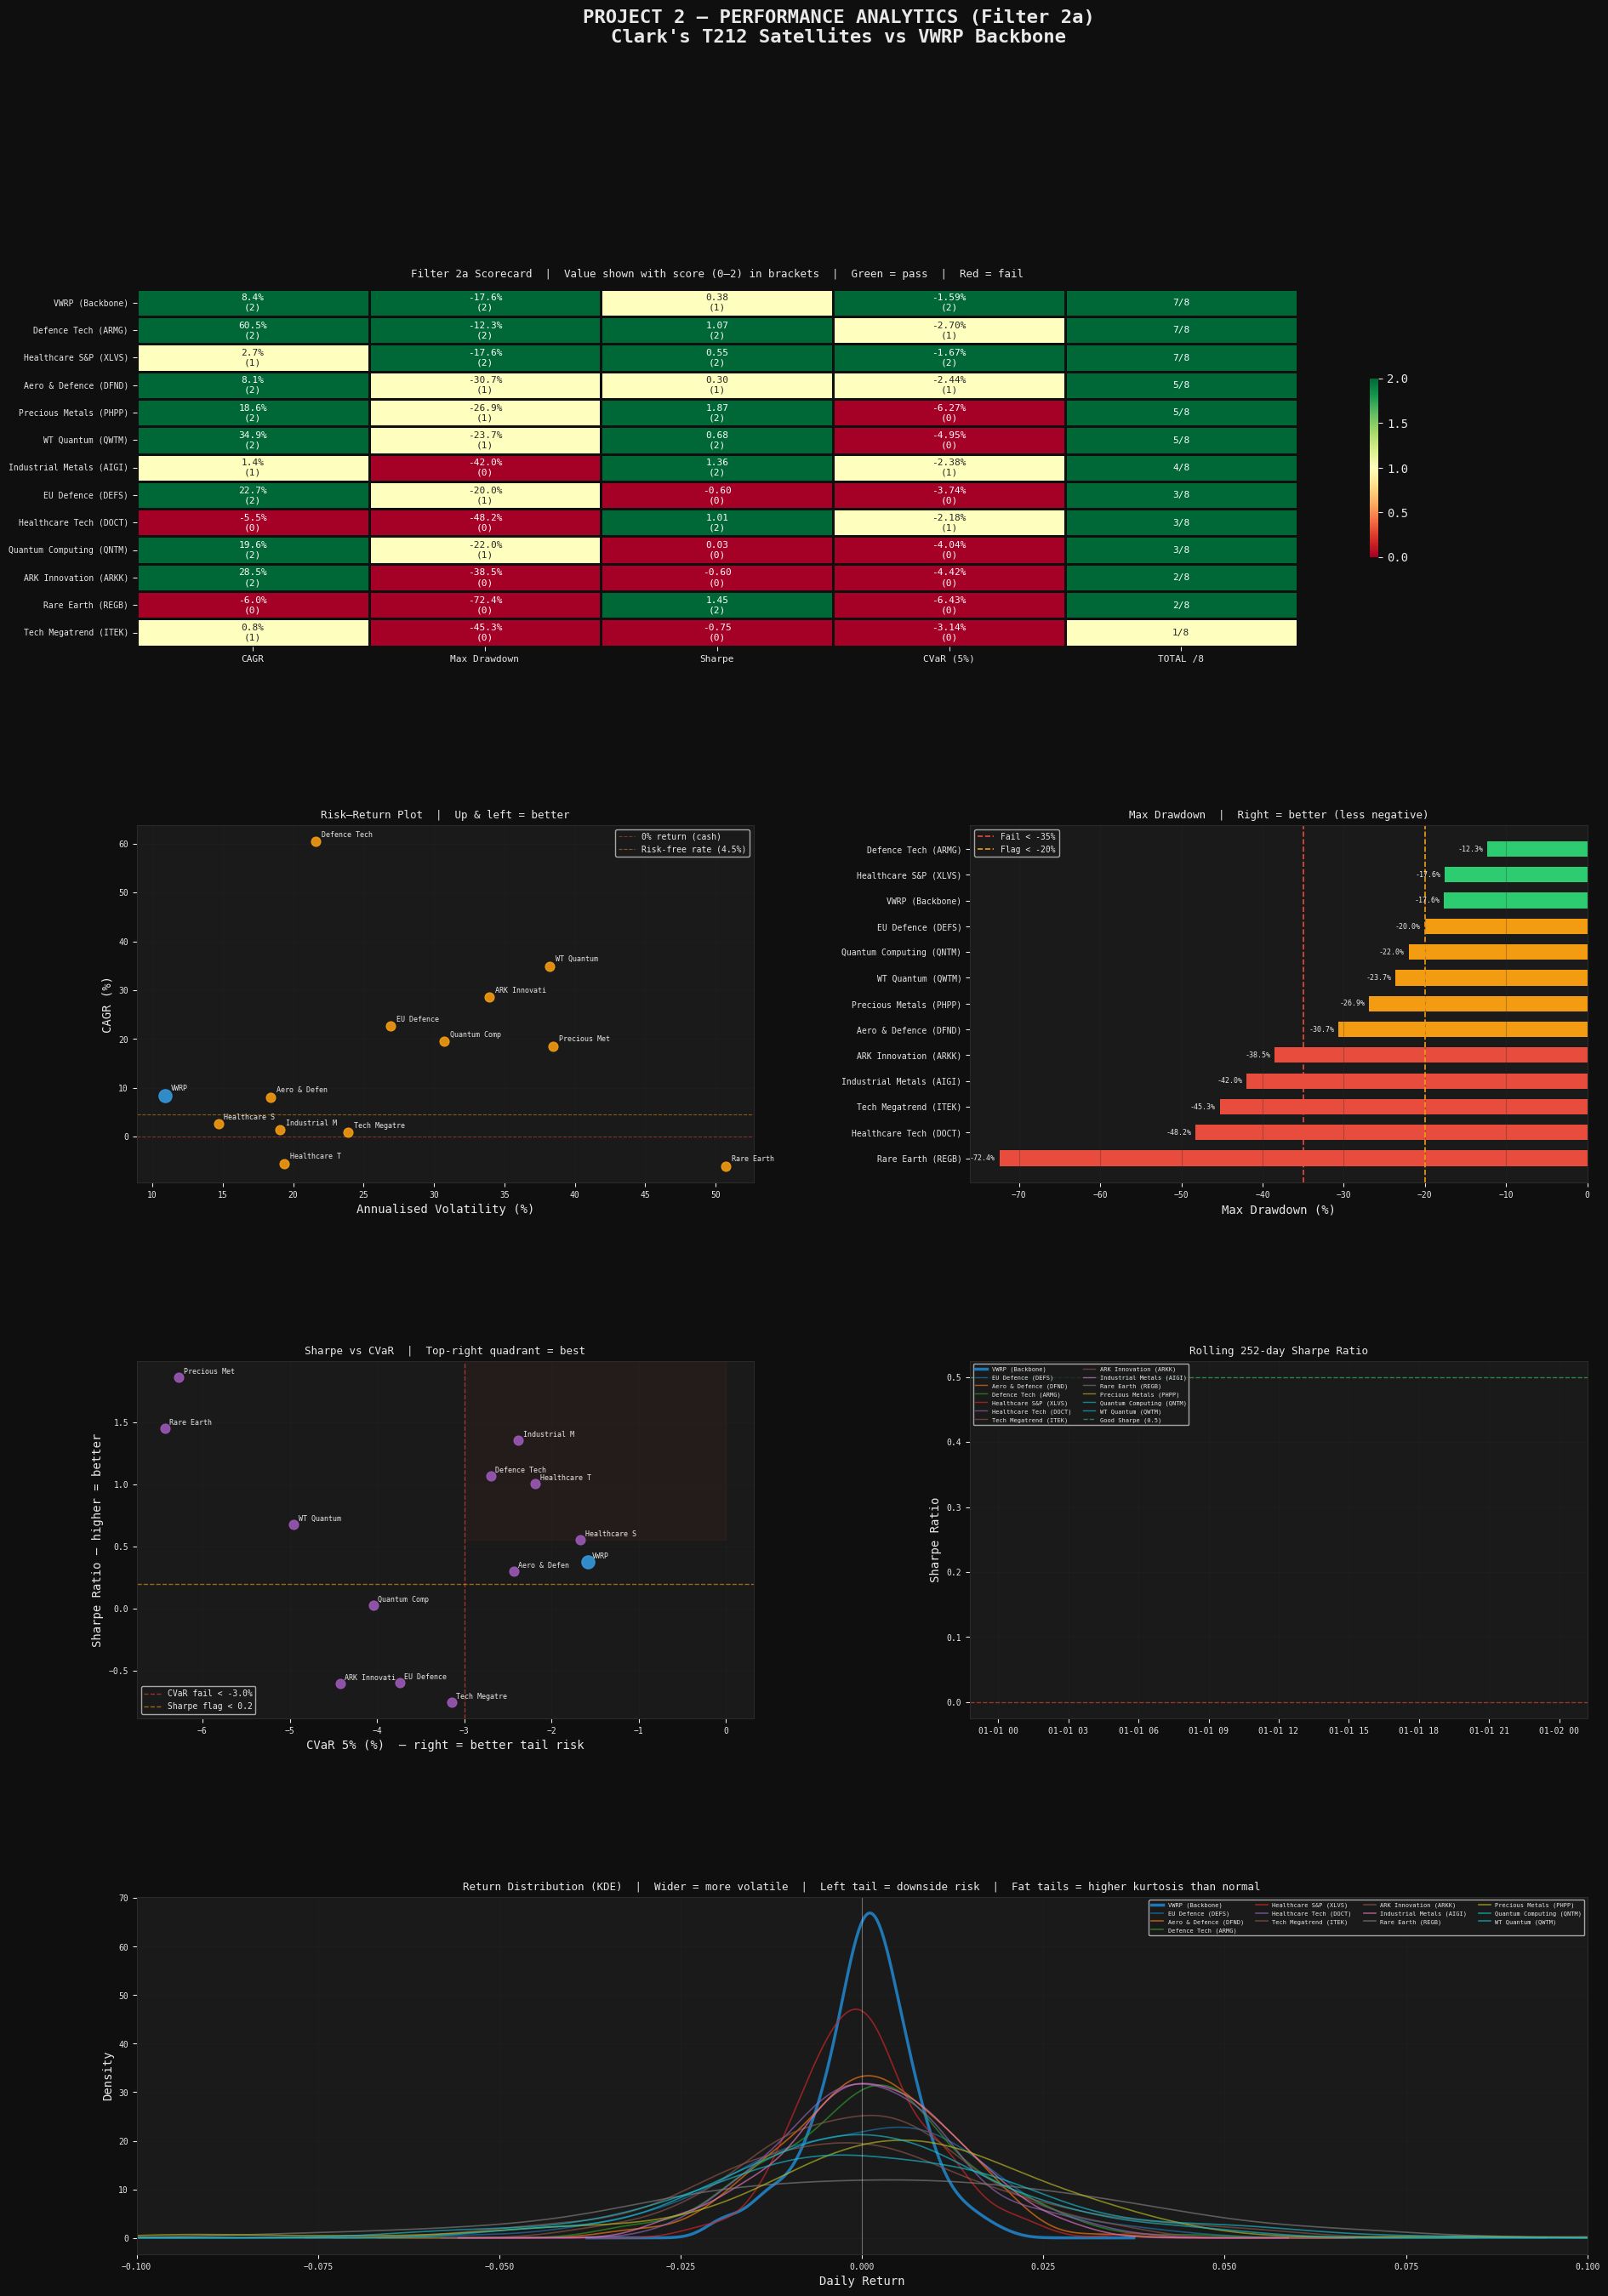


╔══════════════════════════════════════════════════════════════╗
║  PROJECT 2 COMPLETE — HANDOFF TO PROJECT 3                   ║
╠══════════════════════════════════════════════════════════════╣
║  Take the ✅ Proceed holdings into Project 3.                ║
║  Manually review ⚠️  Borderline against your qualitative     ║
║  conviction gate — if the structural thesis is strong,       ║
║  a borderline score can still justify inclusion.             ║
║                                                              ║
║  Project 3 will size the survivors using:                    ║
║    → Risk Parity (default)                                   ║
║    → Constrained MVO (comparison)                            ║
╚══════════════════════════════════════════════════════════════╝



In [1]:
"""
============================================================
 PROJECT 2 — PERFORMANCE ANALYTICS
 Clark's T212 Satellite Portfolio vs VWRP Backbone
============================================================

PIPELINE POSITION:
  This is Filter 2a. It receives the survivors from
  Project 1 (Filter 0 + Filter 1 + Filter 2b) and scores
  each on four performance dimensions.

  Survivors here proceed to Project 3: Position Sizing.

METRICS:
  CAGR         → Compound Annual Growth Rate
                 The geometrically-compounded annual return.
                 Embeds volatility drag — the honest return figure.

  Max Drawdown → Worst peak-to-trough loss in the period.
                 A behavioural risk metric as much as a
                 statistical one — tests whether you could
                 psychologically survive holding this asset.

  Sharpe Ratio → (CAGR - Risk Free Rate) / Annualised Volatility
                 Excess return per unit of total risk.
                 Limitation: assumes normally distributed returns.

  CVaR (5%)    → Conditional Value at Risk at 5% confidence.
                 Average return on the worst 5% of days.
                 Also called Expected Shortfall.
                 Fixes Sharpe's blind spot — captures the
                 CHARACTER of the left tail, not just its width.

KEY CONCEPTS:
  Volatility Drag     → High volatility mathematically reduces
                        geometric mean return below arithmetic mean.
                        CAGR already accounts for this — raw average
                        return does not.

  Fat Tails           → Real asset returns have more extreme events
                        than a normal distribution predicts.
                        CVaR captures this where Sharpe cannot.

  Return Distribution → All four metrics together sketch the shape:
                        CAGR = centre | Vol = width | 
                        Max DD = worst path | CVaR = left tail
============================================================
"""

# ── IMPORTS ──────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════

# ── Full holdings dict (same as Project 1) ────────────────
HOLDINGS = {
    'VWRP.L':  'VWRP (Backbone)',
    'DEFS.L':  'EU Defence (DEFS)',
    'DFND.L':  'Aero & Defence (DFND)',
    'ARMG.L':  'Defence Tech (ARMG)',
    'XLVS.L':  'Healthcare S&P (XLVS)',
    'DOCT.L':  'Healthcare Tech (DOCT)',
    'SMGB.L':  'Semiconductors (SMGB)',
    'VFEG.L':  'Emerging Markets (VFEG)',
    'ITEK.L':  'Tech Megatrend (ITEK)',
    'ARKK.L':  'ARK Innovation (ARKK)',
    'AIGI.L':  'Industrial Metals (AIGI)',
    'REGB.L':  'Rare Earth (REGB)',
    'PHPP.L':  'Precious Metals (PHPP)',
    'QNTM.L':  'Quantum Computing (QNTM)',
    'QWTM.L':  'WT Quantum (QWTM)',
    'FCHP.L':  'Global Semi (FCHP)',
}

# ── Paste your Project 1 survivors here ───────────────────
# These are the short names (values from HOLDINGS dict)
# that passed Filter 0 + Filter 1 + Filter 2b.
# VWRP is always included as the benchmark.
# Example below — update with your actual Project 1 output.
PROJECT1_SURVIVORS = [
    'VWRP (Backbone)',
    'EU Defence (DEFS)',
    'Aero & Defence (DFND)',
    'Defence Tech (ARMG)',
    'Healthcare S&P (XLVS)',
    'Healthcare Tech (DOCT)',
    'Tech Megatrend (ITEK)',
    'ARK Innovation (ARKK)',
    'Industrial Metals (AIGI)',
    'Rare Earth (REGB)',
    'Precious Metals (PHPP)',
    'Quantum Computing (QNTM)',
    'WT Quantum (QWTM)',
]
# ^ Edit this list based on your Project 1 results.
#   If you want to run all holdings regardless, set:
#   PROJECT1_SURVIVORS = list(HOLDINGS.values())

BACKBONE      = 'VWRP.L'
START_DATE    = '2022-01-01'
END_DATE      = '2026-03-27'

# ── Performance thresholds ────────────────────────────────
# These define pass/flag/fail for each metric.
# Benchmarked against VWRP's expected long-run profile.

RISK_FREE_RATE = 0.045        # ~UK base rate as of early 2026 (annualised)
                               # Used in Sharpe ratio calculation.
                               # Update this if rates change materially.

CAGR_FLAG      = 0.00         # Below 0% → failing to beat cash
CAGR_PASS      = 0.05         # Above 5% → acceptable long-run return

DRAWDOWN_FLAG  = -0.35        # Worse than -35% → serious concern
DRAWDOWN_PASS  = -0.20        # Better than -20% → acceptable

SHARPE_FLAG    = 0.20         # Below 0.20 → poor risk-adjusted return
SHARPE_PASS    = 0.50         # Above 0.50 → solid risk-adjusted return

CVAR_FLAG      = -0.030       # Worse than -3.0% avg on bad days → high tail risk
CVAR_PASS      = -0.020       # Better than -2.0% → acceptable tail risk

CVAR_CONFIDENCE = 0.05        # CVaR at 5% — average of worst 5% of days

# ── Style ─────────────────────────────────────────────────
PALETTE = {
    'background': '#0f0f0f',
    'panel':      '#1a1a1a',
    'text':       '#e8e8e8',
    'green':      '#2ecc71',
    'amber':      '#f39c12',
    'red':        '#e74c3c',
    'blue':       '#3498db',
    'purple':     '#9b59b6',
    'grid':       '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['background'],
    'axes.facecolor':   PALETTE['panel'],
    'axes.edgecolor':   PALETTE['grid'],
    'axes.labelcolor':  PALETTE['text'],
    'xtick.color':      PALETTE['text'],
    'ytick.color':      PALETTE['text'],
    'text.color':       PALETTE['text'],
    'grid.color':       PALETTE['grid'],
    'font.family':      'monospace',
})


# ══════════════════════════════════════════════════════════
#  STEP 1 — DOWNLOAD PRICE DATA
# ══════════════════════════════════════════════════════════

print("\n📥 Downloading price data from Yahoo Finance...")
print(f"   Period: {START_DATE} → {END_DATE}\n")

tickers = list(HOLDINGS.keys())
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

available = [t for t in tickers
             if t in raw.columns and raw[t].notna().sum() > 30]
missing   = [t for t in tickers if t not in available]

if missing:
    print(f"⚠️  Could not retrieve: {missing}\n")

prices = raw[available].dropna(how='all')
short_names = {t: HOLDINGS[t] for t in available if t in HOLDINGS}
prices.rename(columns=short_names, inplace=True)

backbone_name = HOLDINGS[BACKBONE]

# Filter to Project 1 survivors only
survivors_available = [
    s for s in PROJECT1_SURVIVORS
    if s in prices.columns
]
missing_survivors = [
    s for s in PROJECT1_SURVIVORS
    if s not in prices.columns
]
if missing_survivors:
    print(f"⚠️  Survivors not found in price data: {missing_survivors}")

prices_s = prices[survivors_available]

print(f"✅ Analysing {len(survivors_available)} holdings.")
print(f"   Date range: {prices_s.index[0].date()} → {prices_s.index[-1].date()}\n")


# ══════════════════════════════════════════════════════════
#  STEP 2 — DAILY RETURNS
# ══════════════════════════════════════════════════════════

returns = prices_s.pct_change().dropna()


# ══════════════════════════════════════════════════════════
#  STEP 3 — PERFORMANCE METRIC FUNCTIONS
# ══════════════════════════════════════════════════════════

def compute_cagr(prices_series):
    """
    Compound Annual Growth Rate.

    Formula: (End / Start) ^ (1 / years) - 1

    WHY geometric not arithmetic?
    Arithmetic mean of [+50%, -50%] = 0% — suggests no loss.
    Geometric mean = (1.5 × 0.5)^0.5 - 1 = -13.4% — the truth.

    Volatility mathematically erodes arithmetic returns.
    This is called VOLATILITY DRAG and it's why high-volatility
    assets need substantially higher gross returns to justify
    their risk profile.
    """
    prices_clean = prices_series.dropna()
    if len(prices_clean) < 2:
        return np.nan
    n_years = len(prices_clean) / 252   # 252 trading days per year
    return (prices_clean.iloc[-1] / prices_clean.iloc[0]) ** (1 / n_years) - 1


def compute_max_drawdown(prices_series):
    """
    Maximum Drawdown.

    Formula: (Trough - Peak) / Peak
    Measures the worst peak-to-trough loss over the full period.

    WHY this matters beyond Sharpe:
    It's a BEHAVIOURAL risk metric. An asset with -60% max
    drawdown requires +150% to recover. Empirically, most
    retail investors sell before the recovery arrives —
    locking in the loss permanently.

    Max drawdown therefore tests not just mathematical risk
    but whether you could psychologically survive holding
    the asset through its worst period.
    """
    prices_clean = prices_series.dropna()
    if len(prices_clean) < 2:
        return np.nan
    rolling_max  = prices_clean.cummax()
    drawdowns    = (prices_clean - rolling_max) / rolling_max
    return drawdowns.min()


def compute_sharpe(returns_series, risk_free_rate=RISK_FREE_RATE):
    """
    Sharpe Ratio.

    Formula: (Mean Annual Return - Risk Free Rate) / Annual Volatility
           = Excess return per unit of total risk.

    The risk free rate is the return you could get with
    ZERO risk (UK government bond / base rate). Sharpe
    measures whether you're being compensated for the
    EXTRA risk you're taking vs that baseline.

    LIMITATION: Assumes returns are normally distributed.
    Treats upside and downside volatility identically —
    a great month and a terrible month of equal magnitude
    cancel out in the denominator. This is why CVaR exists.

    Rule of thumb:
      < 0.2  → poor
      0.2–0.5 → acceptable
      0.5–1.0 → good
      > 1.0  → excellent (rare for diversified assets)
    """
    r = returns_series.dropna()
    if len(r) < 20:
        return np.nan
    annual_return = r.mean() * 252
    annual_vol    = r.std()  * np.sqrt(252)
    if annual_vol == 0:
        return np.nan
    return (annual_return - risk_free_rate) / annual_vol


def compute_cvar(returns_series, confidence=CVAR_CONFIDENCE):
    """
    Conditional Value at Risk (CVaR) / Expected Shortfall.

    Formula: Mean of returns below the confidence-level quantile.
    e.g. CVaR(5%) = average return on the worst 5% of days.

    WHY this fixes Sharpe's blind spot:
    Sharpe uses standard deviation — which is symmetric and
    assumes a bell curve. Real returns have FAT TAILS:
    extreme losses happen more often than a normal distribution
    predicts.

    CVaR directly measures what happens in those tails.
    Two assets with identical Sharpe ratios can have very
    different CVaR if one has occasional catastrophic days.

    For your thematic ETFs: ARKK, QNTM, and similar
    speculative ETFs tend to have much worse CVaR than
    their Sharpe ratio suggests — precisely because of
    sharp, sudden drawdown days.
    """
    r = returns_series.dropna()
    if len(r) < 20:
        return np.nan
    threshold = r.quantile(confidence)
    tail      = r[r <= threshold]
    return tail.mean() if len(tail) > 0 else np.nan


def compute_annualised_vol(returns_series):
    """
    Annualised volatility = daily std × sqrt(252).
    sqrt(252) scales daily volatility to annual —
    derived from the square-root-of-time rule for
    independent random variables (a key stats concept).
    """
    r = returns_series.dropna()
    if len(r) < 20:
        return np.nan
    return r.std() * np.sqrt(252)


def compute_calmar(cagr, max_drawdown):
    """
    Calmar Ratio = CAGR / |Max Drawdown|
    Return per unit of drawdown risk.
    Useful complement to Sharpe for long-horizon investors
    where drawdown survival matters more than daily vol.
    """
    if max_drawdown == 0 or np.isnan(max_drawdown):
        return np.nan
    return cagr / abs(max_drawdown)


# ══════════════════════════════════════════════════════════
#  STEP 4 — COMPUTE ALL METRICS
# ══════════════════════════════════════════════════════════

print("📊 Computing performance metrics...\n")

metrics = {}
for col in survivors_available:
    metrics[col] = {
        'CAGR':        compute_cagr(prices_s[col]),
        'Max Drawdown': compute_max_drawdown(prices_s[col]),
        'Sharpe':      compute_sharpe(returns[col]),
        'CVaR (5%)':   compute_cvar(returns[col]),
        'Ann. Vol':    compute_annualised_vol(returns[col]),
        'Calmar':      compute_calmar(
                           compute_cagr(prices_s[col]),
                           compute_max_drawdown(prices_s[col])
                       ),
    }

metrics_df = pd.DataFrame(metrics).T


# ══════════════════════════════════════════════════════════
#  STEP 5 — VERDICT SYSTEM
# ══════════════════════════════════════════════════════════
# Each metric gets a traffic light score: 2 (pass), 1 (flag), 0 (fail).
# Total score out of 8 determines overall Filter 2a verdict.
# An asset must score ≥ 5/8 to proceed to Project 3.

def score_cagr(v):
    if np.isnan(v):     return 0
    if v >= CAGR_PASS:  return 2
    if v >= CAGR_FLAG:  return 1
    return 0

def score_drawdown(v):
    if np.isnan(v):          return 0
    if v >= DRAWDOWN_PASS:   return 2
    if v >= DRAWDOWN_FLAG:   return 1
    return 0

def score_sharpe(v):
    if np.isnan(v):       return 0
    if v >= SHARPE_PASS:  return 2
    if v >= SHARPE_FLAG:  return 1
    return 0

def score_cvar(v):
    if np.isnan(v):      return 0
    if v >= CVAR_PASS:   return 2
    if v >= CVAR_FLAG:   return 1
    return 0

def traffic_light(score, max_score=2):
    if score == max_score: return '✅'
    if score == 1:         return '⚠️ '
    return '❌'

metrics_df['Score_CAGR'] = metrics_df['CAGR'].apply(score_cagr)
metrics_df['Score_DD']   = metrics_df['Max Drawdown'].apply(score_drawdown)
metrics_df['Score_Sh']   = metrics_df['Sharpe'].apply(score_sharpe)
metrics_df['Score_CV']   = metrics_df['CVaR (5%)'].apply(score_cvar)
metrics_df['Total Score'] = (
    metrics_df['Score_CAGR'] +
    metrics_df['Score_DD']   +
    metrics_df['Score_Sh']   +
    metrics_df['Score_CV']
)
metrics_df['Verdict'] = metrics_df['Total Score'].apply(
    lambda s: '✅ Proceed to P3' if s >= 5 else
              ('⚠️  Borderline'   if s >= 3 else
               '❌ Cut')
)


# ══════════════════════════════════════════════════════════
#  STEP 6 — ROLLING METRICS
# ══════════════════════════════════════════════════════════
# Static metrics give you one number for the whole period.
# Rolling metrics reveal how that number CHANGES over time —
# essential for understanding whether performance is
# consistent or driven by a single lucky/unlucky window.

ROLL_WINDOW = 252   # 1-year rolling window

rolling_sharpe = (
    returns
    .rolling(ROLL_WINDOW)
    .apply(lambda r: compute_sharpe(pd.Series(r)), raw=False)
)

rolling_vol = (
    returns
    .rolling(ROLL_WINDOW)
    .std() * np.sqrt(252)
)

# Rolling drawdown — current drawdown from rolling peak
rolling_drawdown = pd.DataFrame(index=prices_s.index)
for col in survivors_available:
    p            = prices_s[col].dropna()
    roll_max     = p.cummax()
    rolling_drawdown[col] = (p - roll_max) / roll_max


# ══════════════════════════════════════════════════════════
#  STEP 7 — RETURN DISTRIBUTION ANALYSIS
# ══════════════════════════════════════════════════════════
# Skewness and excess kurtosis quantify the shape of the
# return distribution beyond mean and variance.
#
# SKEWNESS:
#   Negative → left tail is fatter (more large losses than gains)
#   Positive → right tail is fatter (more large gains than losses)
#   We want satellites with low negative skewness.
#
# EXCESS KURTOSIS (kurtosis - 3):
#   > 0 → "fat tails" — more extreme events than normal dist predicts
#   = 0 → matches normal distribution
#   This is why Sharpe underestimates risk for high-kurtosis assets.

dist_stats = pd.DataFrame({
    'Skewness':   returns.skew(),
    'Ex. Kurtosis': returns.kurtosis(),   # pandas returns excess kurtosis
}).loc[survivors_available]


# ══════════════════════════════════════════════════════════
#  PRINT VERDICT TABLE
# ══════════════════════════════════════════════════════════

print("=" * 110)
print("  FILTER 2a — PERFORMANCE ANALYTICS VERDICT")
print(f"  Benchmark: VWRP  |  Risk-free rate: {RISK_FREE_RATE*100:.1f}%  |  "
      f"Pass threshold: ≥ 5/8")
print("=" * 110)
print(f"  {'ETF':<30} {'CAGR':>8} {'Max DD':>8} {'Sharpe':>8} "
      f"{'CVaR5%':>8} {'Vol':>7} {'Score':>7}   Verdict")
print("-" * 110)

for etf, row in metrics_df.sort_values('Total Score', ascending=False).iterrows():
    is_backbone = etf == backbone_name
    cagr_tl = traffic_light(row['Score_CAGR'])
    dd_tl   = traffic_light(row['Score_DD'])
    sh_tl   = traffic_light(row['Score_Sh'])
    cv_tl   = traffic_light(row['Score_CV'])
    label   = f"{'★ ' if is_backbone else '  '}{etf}"
    print(
        f"  {label:<30} "
        f"{cagr_tl}{row['CAGR']*100:>5.1f}%  "
        f"{dd_tl}{row['Max Drawdown']*100:>5.1f}%  "
        f"{sh_tl}{row['Sharpe']:>5.2f}   "
        f"{cv_tl}{row['CVaR (5%)']*100:>5.2f}%  "
        f"{row['Ann. Vol']*100:>5.1f}%  "
        f"{row['Total Score']:>4.0f}/8   "
        f"{row['Verdict']}"
    )

print("=" * 110)

filter2a_pass = metrics_df[metrics_df['Total Score'] >= 5].index.tolist()
filter2a_flag = metrics_df[
    (metrics_df['Total Score'] >= 3) &
    (metrics_df['Total Score'] < 5)
].index.tolist()
filter2a_cut  = metrics_df[metrics_df['Total Score'] < 3].index.tolist()

print(f"\n  ✅ Proceed to Project 3: {filter2a_pass}")
print(f"  ⚠️  Borderline (review manually): {filter2a_flag}")
print(f"  ❌ Cut: {filter2a_cut}\n")

# Distribution stats
print("=" * 65)
print("  RETURN DISTRIBUTION STATS")
print("  Negative skewness = more large losses than gains")
print("  Excess kurtosis > 0 = fatter tails than normal dist")
print("=" * 65)
print(f"  {'ETF':<30} {'Skewness':>10} {'Ex. Kurtosis':>14}")
print("-" * 65)
for etf, row in dist_stats.sort_values('Ex. Kurtosis', ascending=False).iterrows():
    sk_flag = '⚠️ ' if row['Skewness'] < -0.5       else '   '
    kt_flag = '⚠️ ' if row['Ex. Kurtosis'] > 3.0    else '   '
    print(f"  {etf:<30} {sk_flag}{row['Skewness']:>8.3f} "
          f"{kt_flag}{row['Ex. Kurtosis']:>12.3f}")
print("=" * 65)


# ══════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 30))
fig.suptitle(
    "PROJECT 2 — PERFORMANCE ANALYTICS (Filter 2a)\n"
    "Clark's T212 Satellites vs VWRP Backbone",
    fontsize=16, fontweight='bold',
    color=PALETTE['text'], y=0.99
)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)


# Chart 1: Metric Scorecard Heatmap ───────────────────────
ax1 = fig.add_subplot(gs[0, :])

score_cols = ['Score_CAGR', 'Score_DD', 'Score_Sh', 'Score_CV', 'Total Score']
score_display = metrics_df[score_cols].copy()
score_display.columns = ['CAGR', 'Max Drawdown', 'Sharpe', 'CVaR (5%)', 'TOTAL /8']
score_display_sorted = score_display.sort_values('TOTAL /8', ascending=False)

# Custom annotation: show actual values not just scores
annot_data = pd.DataFrame(index=score_display_sorted.index,
                          columns=score_display_sorted.columns)
for etf in score_display_sorted.index:
    r = metrics_df.loc[etf]
    annot_data.loc[etf, 'CAGR']          = f"{r['CAGR']*100:.1f}%\n({int(r['Score_CAGR'])})"
    annot_data.loc[etf, 'Max Drawdown']  = f"{r['Max Drawdown']*100:.1f}%\n({int(r['Score_DD'])})"
    annot_data.loc[etf, 'Sharpe']        = f"{r['Sharpe']:.2f}\n({int(r['Score_Sh'])})"
    annot_data.loc[etf, 'CVaR (5%)']     = f"{r['CVaR (5%)']*100:.2f}%\n({int(r['Score_CV'])})"
    annot_data.loc[etf, 'TOTAL /8']      = f"{int(r['Total Score'])}/8"

sns.heatmap(
    score_display_sorted.astype(float),
    annot=annot_data,
    fmt='',
    cmap='RdYlGn',
    vmin=0, vmax=2,
    linewidths=0.8,
    linecolor=PALETTE['background'],
    annot_kws={'size': 8},
    ax=ax1,
    cbar_kws={'shrink': 0.5}
)
ax1.set_title(
    'Filter 2a Scorecard  |  Value shown with score (0–2) in brackets  |  '
    'Green = pass  |  Red = fail',
    fontsize=9, pad=10
)
ax1.tick_params(axis='x', rotation=0,  labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=7)


# Chart 2: CAGR vs Volatility scatter ─────────────────────
# The classic risk-return plot. Assets above the diagonal
# are delivering more return per unit of risk than average.
# VWRP should anchor the comparison.
ax2 = fig.add_subplot(gs[1, 0])

for etf in survivors_available:
    r   = metrics_df.loc[etf]
    col = PALETTE['blue'] if etf == backbone_name else PALETTE['amber']
    sz  = 120 if etf == backbone_name else 60
    ax2.scatter(r['Ann. Vol'] * 100, r['CAGR'] * 100,
                color=col, s=sz, zorder=5, alpha=0.9)
    ax2.annotate(
        etf.split('(')[0].strip()[:12],
        (r['Ann. Vol'] * 100, r['CAGR'] * 100),
        textcoords='offset points', xytext=(5, 4),
        fontsize=6, color=PALETTE['text']
    )

ax2.axhline(0, color=PALETTE['red'],  lw=0.8, ls='--', alpha=0.5,
            label='0% return (cash)')
ax2.axhline(RISK_FREE_RATE * 100, color=PALETTE['amber'], lw=0.8, ls='--',
            alpha=0.5, label=f'Risk-free rate ({RISK_FREE_RATE*100:.1f}%)')
ax2.set_xlabel('Annualised Volatility (%)')
ax2.set_ylabel('CAGR (%)')
ax2.set_title('Risk–Return Plot  |  Up & left = better', fontsize=9)
ax2.legend(fontsize=7)
ax2.grid(alpha=0.2)
ax2.tick_params(labelsize=7)


# Chart 3: Max Drawdown bar chart ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
dd_sorted = metrics_df['Max Drawdown'].sort_values()
dd_colours = [
    PALETTE['red']   if v < DRAWDOWN_FLAG   else
    PALETTE['amber'] if v < DRAWDOWN_PASS   else
    PALETTE['green']
    for v in dd_sorted.values
]
bars = ax3.barh(dd_sorted.index, dd_sorted.values * 100,
                color=dd_colours, edgecolor='none', height=0.6)
ax3.axvline(DRAWDOWN_FLAG * 100, color=PALETTE['red'],   ls='--', lw=1.2,
            label=f'Fail < {DRAWDOWN_FLAG*100:.0f}%')
ax3.axvline(DRAWDOWN_PASS * 100, color=PALETTE['amber'], ls='--', lw=1.2,
            label=f'Flag < {DRAWDOWN_PASS*100:.0f}%')
ax3.set_xlabel('Max Drawdown (%)')
ax3.set_title('Max Drawdown  |  Right = better (less negative)', fontsize=9)
ax3.legend(fontsize=7)
ax3.grid(axis='x', alpha=0.3)
ax3.tick_params(labelsize=7)
for bar, val in zip(bars, dd_sorted.values):
    ax3.text(val * 100 - 0.5, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', ha='right',
             fontsize=6, color=PALETTE['text'])


# Chart 4: Sharpe vs CVaR scatter ─────────────────────────
# The KEY chart for understanding the Sharpe blind spot.
# Assets in the top-right quadrant have BOTH good
# risk-adjusted returns AND acceptable tail risk.
# Assets that look fine on Sharpe but have terrible CVaR
# are the dangerous ones — they appear in the top-left.
ax4 = fig.add_subplot(gs[2, 0])

for etf in survivors_available:
    r   = metrics_df.loc[etf]
    col = PALETTE['blue'] if etf == backbone_name else PALETTE['purple']
    sz  = 120 if etf == backbone_name else 60
    ax4.scatter(r['CVaR (5%)'] * 100, r['Sharpe'],
                color=col, s=sz, zorder=5, alpha=0.9)
    ax4.annotate(
        etf.split('(')[0].strip()[:12],
        (r['CVaR (5%)'] * 100, r['Sharpe']),
        textcoords='offset points', xytext=(4, 3),
        fontsize=6, color=PALETTE['text']
    )

ax4.axvline(CVAR_FLAG * 100,  color=PALETTE['red'],   ls='--', lw=1,
            alpha=0.6, label=f'CVaR fail < {CVAR_FLAG*100:.1f}%')
ax4.axhline(SHARPE_FLAG, color=PALETTE['amber'], ls='--', lw=1,
            alpha=0.6, label=f'Sharpe flag < {SHARPE_FLAG}')

# Shade the "good" quadrant
ax4.axvspan(CVAR_FLAG * 100, 0,
            ymin=0.5, alpha=0.05, color=PALETTE['red'])

ax4.set_xlabel('CVaR 5% (%)  — right = better tail risk')
ax4.set_ylabel('Sharpe Ratio — higher = better')
ax4.set_title('Sharpe vs CVaR  |  Top-right quadrant = best', fontsize=9)
ax4.legend(fontsize=7)
ax4.grid(alpha=0.2)
ax4.tick_params(labelsize=7)


# Chart 5: Rolling Sharpe ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
cmap_lines = plt.cm.tab10(np.linspace(0, 1, len(survivors_available)))
for col, colour in zip(survivors_available, cmap_lines):
    if col in rolling_sharpe.columns:
        lw    = 2.5 if col == backbone_name else 1.0
        alpha = 1.0 if col == backbone_name else 0.65
        ax5.plot(rolling_sharpe.index, rolling_sharpe[col],
                 label=col, lw=lw, color=colour, alpha=alpha)
ax5.axhline(0,           color=PALETTE['red'],   ls='--', lw=1, alpha=0.6)
ax5.axhline(SHARPE_PASS, color=PALETTE['green'], ls='--', lw=1, alpha=0.6,
            label=f'Good Sharpe ({SHARPE_PASS})')
ax5.set_title(f'Rolling {ROLL_WINDOW}-day Sharpe Ratio', fontsize=9)
ax5.set_ylabel('Sharpe Ratio')
ax5.legend(fontsize=5, ncol=2, loc='upper left')
ax5.grid(alpha=0.2)
ax5.tick_params(labelsize=7)


# Chart 6: Return distribution — KDE per asset ────────────
# Visualises the SHAPE of each asset's return distribution.
# Wide/flat = high volatility | Long left tail = bad skew
# Fat tails visible as distributions wider than a normal curve.
ax6 = fig.add_subplot(gs[3, :])
for col, colour in zip(survivors_available, cmap_lines):
    if col in returns.columns:
        r_clean = returns[col].dropna()
        lw    = 2.5 if col == backbone_name else 1.2
        alpha = 1.0 if col == backbone_name else 0.65
        r_clean.plot.kde(ax=ax6, label=col, lw=lw,
                         color=colour, alpha=alpha)

ax6.axvline(0, color=PALETTE['text'], lw=0.8, alpha=0.4)
ax6.set_xlim(-0.10, 0.10)
ax6.set_xlabel('Daily Return')
ax6.set_ylabel('Density')
ax6.set_title(
    'Return Distribution (KDE)  |  '
    'Wider = more volatile  |  Left tail = downside risk  |  '
    'Fat tails = higher kurtosis than normal',
    fontsize=9
)
ax6.legend(fontsize=5, ncol=4, loc='upper right')
ax6.grid(alpha=0.2)
ax6.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# ══════════════════════════════════════════════════════════
#  SUMMARY
# ══════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║  PROJECT 2 COMPLETE — HANDOFF TO PROJECT 3                   ║
╠══════════════════════════════════════════════════════════════╣
║  Take the ✅ Proceed holdings into Project 3.                ║
║  Manually review ⚠️  Borderline against your qualitative     ║
║  conviction gate — if the structural thesis is strong,       ║
║  a borderline score can still justify inclusion.             ║
║                                                              ║
║  Project 3 will size the survivors using:                    ║
║    → Risk Parity (default)                                   ║
║    → Constrained MVO (comparison)                            ║
╚══════════════════════════════════════════════════════════════╝
""")